In [1]:
# importing necessary libs
import piplite
await piplite.install("pandas")
import piplite
await piplite.install("numpy")
import piplite
await piplite.install("seaborn")
import piplite
await piplite.install("matplotlib")
import piplite
await piplite.install("scikit-learn")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [4]:
wdf = pd.read_csv('Lab 22 winequality-red.csv')
wdf.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [6]:
def log_transform(col):
    return np.log(col)
wdf['residual sugar'] = wdf[['residual sugar']].apply(log_transform, axis=1)
wdf['chlorides'] = wdf[['chlorides']].apply(log_transform, axis=1)
wdf['free sulfur dioxide'] = wdf[['free sulfur dioxide']].apply(log_transform, axis=1)
wdf['total sulfur dioxide'] = wdf[['total sulfur dioxide']].apply(log_transform, axis=1)
wdf['sulphates'] = wdf[['sulphates']].apply(log_transform, axis=1)


In [7]:
# split the dataset
x = wdf.drop(columns=['quality'])
y = wdf['quality']

In [8]:
y.head()

0    5
1    5
2    5
3    6
4    5
Name: quality, dtype: int64

In [10]:
import piplite
await piplite.install("imblearn")

In [11]:
from imblearn.over_sampling import SMOTE
oversample = SMOTE(k_neighbors=4)
x, y = oversample.fit_resample(x.fillna(0),y)

/lib/python3.14/site-packages/threadpoolctl.py:1135: RuntimeWarning: JsProxy.as_object_map() is deprecated. Use as_py_json() instead.
  for filepath in LDSO.loadedLibsByName.as_object_map():


In [12]:
y.value_counts()

quality
5    681
6    681
7    681
4    681
8    681
3    681
Name: count, dtype: int64

In [13]:
x_train, x_test, y_train, y_test = train_test_split(x,y,
                                                   test_size=0.2,
                                                   random_state=42)

In [14]:
x_train.shape, x_test.shape

((3268, 11), (818, 11))

In [17]:
# 1. logistic regression - sigmoid function
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression()
lr_model.fit(x_train, y_train)
lr_pred = lr_model.predict(x_test)
lr_pred

/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array([3, 5, 7, 7, 5, 4, 5, 3, 5, 4, 8, 7, 5, 3, 8, 5, 6, 5, 8, 4, 7, 3,
       5, 5, 5, 3, 7, 3, 4, 7, 7, 3, 7, 8, 3, 6, 6, 8, 4, 7, 8, 8, 5, 7,
       8, 4, 7, 4, 5, 7, 3, 6, 6, 6, 6, 3, 4, 7, 3, 4, 6, 6, 3, 4, 8, 4,
       3, 8, 7, 5, 4, 3, 5, 3, 6, 5, 3, 3, 6, 3, 7, 7, 6, 7, 5, 8, 8, 3,
       7, 4, 3, 6, 6, 3, 4, 6, 4, 6, 7, 8, 5, 8, 4, 5, 5, 4, 4, 3, 7, 7,
       4, 3, 7, 5, 5, 6, 3, 8, 3, 5, 5, 5, 8, 5, 6, 7, 7, 4, 5, 6, 6, 7,
       4, 4, 4, 3, 8, 5, 5, 3, 8, 4, 4, 3, 7, 8, 7, 7, 8, 6, 4, 5, 5, 5,
       5, 4, 3, 8, 7, 8, 4, 4, 7, 6, 6, 3, 8, 7, 5, 4, 5, 7, 4, 4, 8, 7,
       4, 3, 7, 5, 3, 6, 8, 7, 7, 6, 4, 4, 7, 7, 7, 5, 6, 6, 6, 6, 4, 3,
       4, 7, 8, 8, 3, 5, 3, 8, 4, 5, 4, 6, 7, 7, 6, 5, 8, 7, 6, 5, 4, 4,
       5, 3, 8, 7, 6, 3, 5, 3, 6, 7, 8, 3, 8, 6, 5, 5, 8, 7, 4, 6, 4, 8,
       3, 3, 6, 4, 6, 7, 8, 8, 6, 7, 8, 8, 6, 7, 5, 6, 5, 5, 3, 8, 3, 8,
       7, 3, 6, 7, 7, 3, 7, 3, 4, 7, 3, 4, 5, 8, 3, 7, 5, 8, 3, 6, 5, 5,
       4, 4, 4, 8, 8, 3, 6, 5, 8, 3, 3, 5, 7, 4, 4,

In [19]:
# accuracy
acc = accuracy_score(y_test, lr_pred)
acc * 100

52.81173594132029

In [20]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, lr_pred)
cm

array([[112,  12,   7,   1,   0,   0],
       [ 23,  57,  28,  23,   0,   0],
       [ 12,  28,  82,  17,  11,   0],
       [ 13,  29,  37,  36,  25,  15],
       [  2,   9,   2,  14,  56,  33],
       [  0,   0,   0,   0,  45,  89]], dtype=int64)

In [23]:
from sklearn.ensemble import RandomForestClassifier
rfc_model = RandomForestClassifier()
rfc_model.fit(x_train, y_train)
rfc_pred = rfc_model.predict(x_test)
acc_rfc = accuracy_score(y_test, rfc_pred)
acc_rfc * 100

86.67481662591688

<h1>Unsepervised ML - K Means Clustering</h1>

In [24]:
from sklearn.cluster import KMeans

In [27]:
# load dataset 
df = pd.read_csv('Lab 23 Wholesale customers data.csv')
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [28]:
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [29]:
# standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
pd.DataFrame(df_scaled)

,0,1,2,3,4,5,6,7
0,1.448652,0.590668,0.052933,0.523568,-0.041115,-0.589367,-0.043569,-0.066339
1,1.448652,0.590668,-0.391302,0.544458,0.170318,-0.270136,0.086407,0.089151
2,1.448652,0.590668,-0.447029,0.408538,-0.028157,-0.137536,0.133232,2.243293
3,-0.690297,0.590668,0.100111,-0.624020,-0.392977,0.687144,-0.498588,0.093411
4,1.448652,0.590668,0.840239,-0.052396,-0.079356,0.173859,-0.231918,1.299347
...,...,...,...,...,...,...,...,...
435,-0.690297,0.590668,1.401312,0.848446,0.850760,2.075222,-0.566831,0.241091
436,-0.690297,0.590668,2.155293,-0.592142,-0.757165,0.296561,-0.585519,0.291501
437,1.448652,0.590668,0.200326,1.314671,2.348386,-0.543380,2.511218,0.121456
438,-0.690297,0.590668,-0.135384,-0.517536,-0.602514,-0.419441,-0.569770,0.213046


In [31]:
# define KMeans and train it
kmeans =KMeans(n_clusters=2, init='k-means++')
# training
kmeans.fit(df_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",2
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


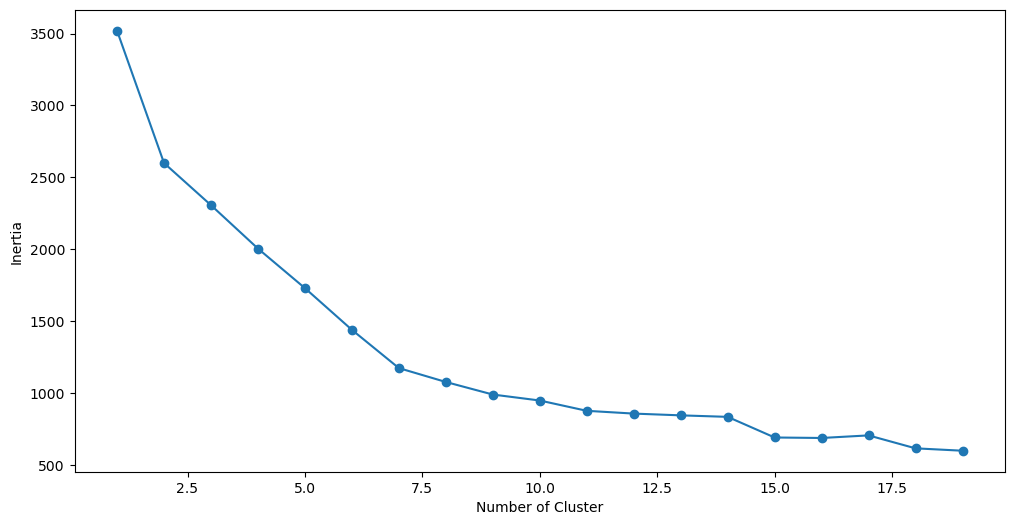

In [32]:
SSE = []
for cluster in range(1, 20):
    kmeans = KMeans(n_clusters=cluster, init='k-means++')
    kmeans.fit(df_scaled)
    SSE.append(kmeans.inertia_)

frame = pd.DataFrame({'Cluster':range(1,20), 'SSE':SSE})
plt.figure(figsize=(12,6))
plt.plot(frame['Cluster'], frame['SSE'], marker='o')
plt.xlabel('Number of Cluster')
plt.ylabel('Inertia')
plt.show()

In [33]:
# for k = 5
kmeans = KMeans(n_clusters=5, init='k-means++')
kmeans.fit(df_scaled)
pred = kmeans.predict(df_scaled)


In [34]:
frame = pd.DataFrame(df_scaled)
frame['cluster']= pred
frame['cluster'].value_counts()

cluster
4    240
3    128
1     57
0     10
2      5
Name: count, dtype: int64

In [35]:
kmeans = KMeans(n_clusters=7, init='k-means++')
kmeans.fit(df_scaled)
pred = kmeans.predict(df_scaled)
frame = pd.DataFrame(df_scaled)
frame['cluster']= pred
frame['cluster'].value_counts()

cluster
0    165
2     98
3     85
4     53
5     32
1      5
6      2
Name: count, dtype: int64

<h1>Simple ANN</h1>

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
cdf=pd.read_csv('Lab 24 breast-cancer-wisconsin.csv')
cdf.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [39]:
cdf['diagnosis'].unique()

<StringArray>
['M', 'B']
Length: 2, dtype: str

In [40]:
cdf.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='str')

In [41]:
cdf.shape

(569, 33)

In [42]:
cdf.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [43]:
cdf.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [46]:
cdf.loc[cdf['diagnosis']=='M', 'benign_0_mal_1'] = 1
cdf.loc[cdf['diagnosis']=='B', 'benign_0_mal_1'] = 0

In [47]:
cdf.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32,benign_0_mal_1
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN,1.0
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN,1.0
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN,1.0
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN,1.0
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN,1.0


In [52]:
# remove cols -> id, diagnosis, Unnamed: 32
cdf = cdf.drop(columns=['id', 'diagnosis', 'Unnamed: 32'])
cdf.columns

Index(['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
       'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'benign_0_mal_1'],
      dtype='str')

<Axes: xlabel='benign_0_mal_1', ylabel='count'>

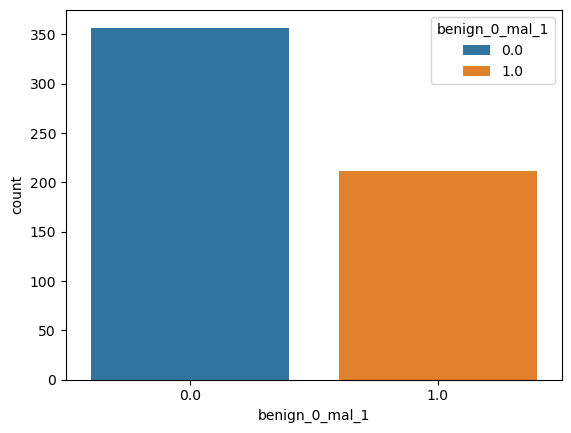

In [53]:
sns.countplot(x='benign_0_mal_1', data=cdf, hue='benign_0_mal_1')

In [54]:
cdf['benign_0_mal_1'].value_counts()

benign_0_mal_1
0.0    357
1.0    212
Name: count, dtype: int64

<Axes: >

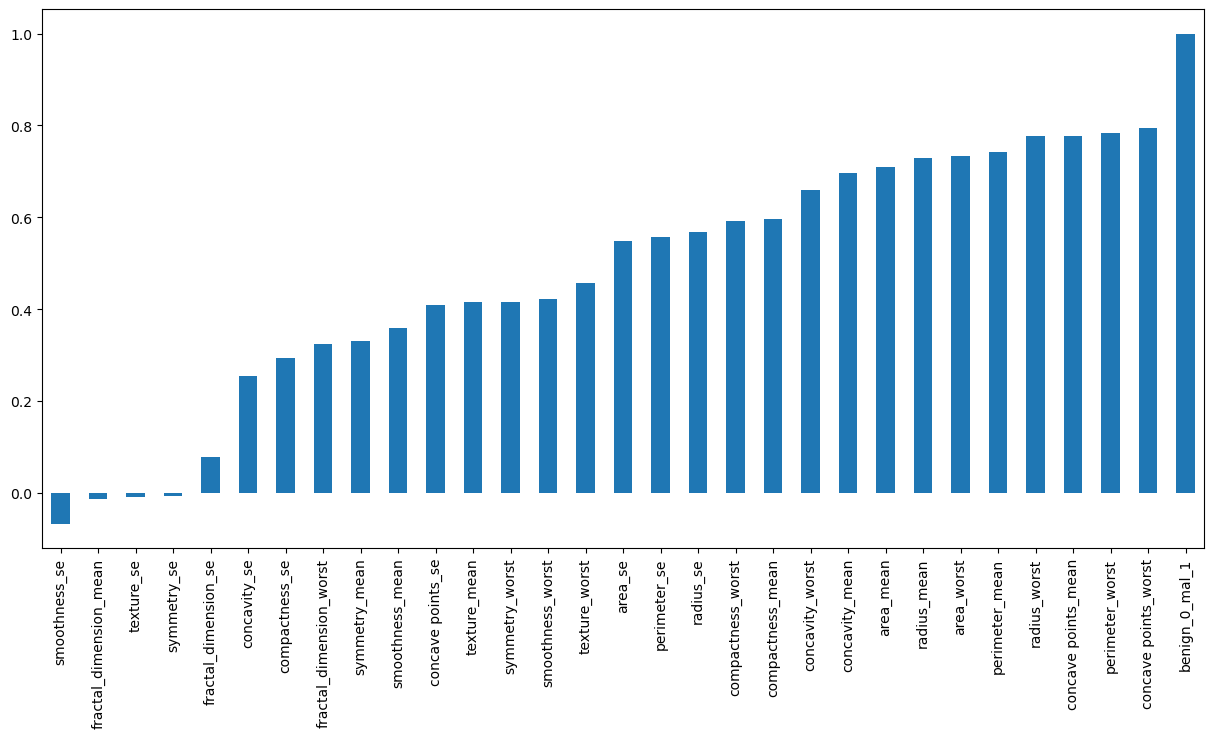

In [56]:
plt.figure(figsize=(15,7))
cdf.corr()['benign_0_mal_1'].sort_values().plot(kind='bar')

In [57]:
# independent var and dependent var
x = cdf.drop(['benign_0_mal_1'], axis=1).values
y = cdf['benign_0_mal_1'].values

In [61]:
# train test split
xtr, xte, ytr, yte = train_test_split(x,y, train_size=0.8, random_state=50)

In [59]:
xtr.shape, xte.shape

((455, 30), (114, 30))

In [60]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
xtr = scaler.fit_transform(xtr)
xte = scaler.transform(xte)     # to prevent data leakages